In [3]:
#Install/import libraries
import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt

from google.colab import files

pd.set_option("display.max_colwidth", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
#Upload cleaned_products.csv
uploaded = files.upload()

Saving cleaned_products.csv to cleaned_products.csv


In [5]:
#Load datatset
df = pd.read_csv("cleaned_products.csv")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

df.head(3)

Dataset loaded successfully.
Shape: (946, 17)


,product_number,asin,search_keyword,title,url,price,description,description_imputed,brand,image,review_count,average_rating,video_url,reviews,review_number_collected,title_length,description_length
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",https://www.amazon.com/Wireless-Sports-Earbuds-Secure-Earhooks/dp/B0HCNYJM8Z/ref=sr_1_1_sspa?dib=eyJ2IjoiMSJ9.Pfr-QAy0JJDOUUkmh_7reL3vGcoeOFG3lAaZ...,25.99,"About this item\r\nSecure Fit for High-Intensity Sports & Specific Ergonomics: Engineered for continuous movement, these earbuds wireless bluetoot...",False,Csasan,https://m.media-amazon.com/images/I/613tyoH+smL._AC_SY300_SX300_QL70_FMwebp_.jpg,9662,4.4,https://m.media-amazon.com/images/S/vse-vms-transcoding-artifact-us-east-1-prod/b9375ae6-81ef-4f19-a07c-bfaa63427c10/default.jobtemplate.hls.m3u8,"[{""reviewer_name"": ""Needsmorenails"", ""star_rating"": 5.0, ""review_title"": ""Durable, Excellent sound, Great value"", ""review_description"": ""While not...",8,196,2969
1,2,B0GFF3RCCL,wireless earbuds,"TALIX T30 Noise Cancelling Earbuds with Phone Stand, Punchy Bass, 4-Mic, True Wireless Bluetooth 6.0 in Ear Headphones, 28H Playtime, IPX4(Off-White)",https://www.amazon.com/TALIX-Cancelling-Bluetooth-Headphones-Off-White/dp/B0GFF3RCCL/ref=sr_1_2_sspa?dib=eyJ2IjoiMSJ9.Pfr-QAy0JJDOUUkmh_7reL3vGcoe...,25.99,"About this item\r\n【Punchy Bass】 Featuring 10mm titanium-composite diaphragm drivers, TALIX T30 noise-cancelling earbuds deliver punchy bass and v...",False,TALIX,https://m.media-amazon.com/images/I/511IigIBpoL._AC_SY300_SX300_QL70_FMwebp_.jpg,67,4.3,https://m.media-amazon.com/images/S/vse-vms-transcoding-artifact-us-east-1-prod/dff626ca-5e78-4019-a607-19e048d5542b/default.jobtemplate.hls.m3u8,"[{""reviewer_name"": ""Michelle"", ""star_rating"": 5.0, ""review_title"": ""Quality budget buds"", ""review_description"": ""Great extra earbuds for the price...",8,149,1544
2,3,B0HBWW3958,wireless earbuds,"Wireless Earbuds, Bluetooth 5.3 Headphones HiFi Stereo 50H Playback LED Digital Display Ear Buds with ENC Noise Canceling Headset, IPX7 Waterproof...",https://www.amazon.com/Fhumsh-Bluetooth-Headphones-Canceling-Waterproof/dp/B0HBWW3958/ref=sr_1_3?dib=eyJ2IjoiMSJ9.Pfr-QAy0JJDOUUkmh_7reL3vGcoeOFG3...,19.98,About this item\r\nSmart LED Display & 50H Sport Headphones: The A10 Bluetooth 5.3 earbuds feature an LED screen that shows real-time power levels...,False,Brand: Fhumsh,https://m.media-amazon.com/images/I/61D5ZCSIymL._AC_SX425_.jpg,196,5.0,https://m.media-amazon.com/images/S/vse-vms-transcoding-artifact-us-east-1-prod/de323d3a-0fde-48b2-a79b-6472bc2f302a/default.jobtemplate.hls.m3u8,"[{""reviewer_name"": ""Mary Santana"", ""star_rating"": 5.0, ""review_title"": ""Beautiful 😍"", ""review_description"": ""I’m really impressed with these wirel...",8,184,2127


#Section 2: Expand Product Reviews

In [6]:
#Parse and expand reviews
review_rows = []

for _, product in df.iterrows():

    try:
        reviews = json.loads(product["reviews"])

    except (json.JSONDecodeError, TypeError):
        continue

    if not isinstance(reviews, list):
        continue

    for review in reviews:

        review_rows.append(
            {
                "product_number": product["product_number"],
                "asin": product["asin"],
                "search_keyword": product["search_keyword"],
                "product_title": product["title"],
                "brand": product["brand"],
                "product_price": product["price"],
                "average_rating": product["average_rating"],

                "reviewer_name": review.get(
                    "reviewer_name",
                    ""
                ),

                "star_rating": review.get(
                    "star_rating",
                    np.nan
                ),

                "review_title": review.get(
                    "review_title",
                    ""
                ),

                "review_description": review.get(
                    "review_description",
                    ""
                ),
            }
        )

reviews_df = pd.DataFrame(review_rows)

print(
    f"Total extracted reviews: "
    f"{len(reviews_df)}"
)

print(
    f"Products represented: "
    f"{reviews_df['asin'].nunique()}"
)

reviews_df.head()

Total extracted reviews: 7494
Products represented: 946


,product_number,asin,search_keyword,product_title,brand,product_price,average_rating,reviewer_name,star_rating,review_title,review_description
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Needsmorenails,5.0,"Durable, Excellent sound, Great value","While not a user of these earbuds, personally, I gave them as gifts to several people. When I asked how the earbuds were doing, I was told that th..."
1,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,J. Marie,5.0,Great Sound Quality,"Pleasantly Surprised. Great sound, easy to use, hold a charge for more than 8 hours. Comfortable even with glasses."
2,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Edie Keepsfire,4.0,"Honestly, shoulda been five except for a 3/5 on call quality, and a couple notes","I've bought these twice. I'll probably buy them a third time. Since they're earbuds, let's talk earbud importance:\n\nCalls:\n\nAlmost gave 3/5 be..."
3,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Stuck in the Desert,5.0,Great Quality! Affordable Price!,I really like these earbuds because they have the ear hook. They are perfect for someone who has small ear canals. I would highly recommend them!
4,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Alicia Martino-Crawford,5.0,Very useful and cute,I mainly use these earbuds when working out at the gym The sound quality is good. I love the secure fit. It's helpful to have the feature where it...


 ## Initial Review Dataset Inspection

In [7]:
print("=" * 60)
print("REVIEW DATASET SUMMARY")
print("=" * 60)

print(f"Total reviews: {len(reviews_df)}")
print(
    f"Unique products: "
    f"{reviews_df['asin'].nunique()}"
)

print("\nDataset structure:")
reviews_df.info()

REVIEW DATASET SUMMARY
Total reviews: 7494
Unique products: 946

Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7494 entries, 0 to 7493
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_number      7494 non-null   int64  
 1   asin                7494 non-null   object 
 2   search_keyword      7494 non-null   object 
 3   product_title       7494 non-null   object 
 4   brand               7494 non-null   object 
 5   product_price       7494 non-null   float64
 6   average_rating      7494 non-null   float64
 7   reviewer_name       7494 non-null   object 
 8   star_rating         7494 non-null   float64
 9   review_title        7494 non-null   object 
 10  review_description  7494 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 644.1+ KB


In [8]:
#Check missing values
missing_reviews = pd.DataFrame({
    "missing_count": reviews_df.isnull().sum(),
    "missing_percentage": (
        reviews_df.isnull().mean() * 100
    ).round(2)
})

display(
    missing_reviews[
        missing_reviews["missing_count"] > 0
    ]
)

,missing_count,missing_percentage


# Section 3 - Review Cleaning and Duplicate Handling

This section cleans the review-level dataset by handling missing text,
removing invalid reviews, and identifying duplicate records.

Text preprocessing is intentionally kept minimal because aggressive cleaning
such as removing stopwords or punctuation may remove useful sentiment signals.

In [9]:
#Inspect Missing Review Content
review_columns = [
    "reviewer_name",
    "star_rating",
    "review_title",
    "review_description",
]

missing_review_summary = pd.DataFrame({
    "missing_count": reviews_df[review_columns].isnull().sum(),
    "missing_percentage": (
        reviews_df[review_columns]
        .isnull()
        .mean()
        .mul(100)
        .round(2)
    ),
})

display(missing_review_summary)

,missing_count,missing_percentage
reviewer_name,0,0.0
star_rating,0,0.0
review_title,0,0.0
review_description,0,0.0


In [10]:
#Basic Text Cleaning
def clean_review_text(text):
    """
    Apply minimal cleaning while preserving
    sentiment-related information.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Replace line breaks and tabs with spaces
    text = re.sub(r"[\n\r\t]+", " ", text)

    # Remove repeated whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [11]:
reviews_df["review_title"] = (
    reviews_df["review_title"]
    .apply(clean_review_text)
)

reviews_df["review_description"] = (
    reviews_df["review_description"]
    .apply(clean_review_text)
)

## Create Combined Review Text
### For sentiment classification, title and description together provide better context.

In [12]:
#Create Combined Review Text
reviews_df["review_text"] = (
    reviews_df["review_title"]
    + ". "
    + reviews_df["review_description"]
).str.strip()

In [13]:
display(
    reviews_df[
        [
            "review_title",
            "review_description",
            "review_text",
        ]
    ].head()
)

,review_title,review_description,review_text
0,"Durable, Excellent sound, Great value","While not a user of these earbuds, personally, I gave them as gifts to several people. When I asked how the earbuds were doing, I was told that th...","Durable, Excellent sound, Great value. While not a user of these earbuds, personally, I gave them as gifts to several people. When I asked how the..."
1,Great Sound Quality,"Pleasantly Surprised. Great sound, easy to use, hold a charge for more than 8 hours. Comfortable even with glasses.","Great Sound Quality. Pleasantly Surprised. Great sound, easy to use, hold a charge for more than 8 hours. Comfortable even with glasses."
2,"Honestly, shoulda been five except for a 3/5 on call quality, and a couple notes","I've bought these twice. I'll probably buy them a third time. Since they're earbuds, let's talk earbud importance: Calls: Almost gave 3/5 because ...","Honestly, shoulda been five except for a 3/5 on call quality, and a couple notes. I've bought these twice. I'll probably buy them a third time. Si..."
3,Great Quality! Affordable Price!,I really like these earbuds because they have the ear hook. They are perfect for someone who has small ear canals. I would highly recommend them!,Great Quality! Affordable Price!. I really like these earbuds because they have the ear hook. They are perfect for someone who has small ear canal...
4,Very useful and cute,I mainly use these earbuds when working out at the gym The sound quality is good. I love the secure fit. It's helpful to have the feature where it...,Very useful and cute. I mainly use these earbuds when working out at the gym The sound quality is good. I love the secure fit. It's helpful to hav...


In [14]:
#Remove Reviews Without Meaningful Text
initial_review_count = len(reviews_df)

reviews_df["review_text"] = (
    reviews_df["review_text"]
    .str.replace(
        r"^\.\s*$",
        "",
        regex=True,
    )
    .str.strip()
)

reviews_df = reviews_df[
    reviews_df["review_text"].ne("")
].copy()

removed_empty_reviews = (
    initial_review_count - len(reviews_df)
)

print(
    f"Empty reviews removed: "
    f"{removed_empty_reviews}"
)

print(
    f"Remaining reviews: "
    f"{len(reviews_df)}"
)

Empty reviews removed: 0
Remaining reviews: 7494


## Handle Duplicate Reviews

In [15]:
#Check duplicate reviews
duplicate_reviews = reviews_df.duplicated(
    subset=[
        "asin",
        "reviewer_name",
        "review_title",
        "review_description",
    ]
).sum()

print(
    f"Duplicate reviews: "
    f"{duplicate_reviews}"
)

Duplicate reviews: 0


In [16]:
#Validate Star Ratings
print("STAR RATING SUMMARY")
print("-" * 40)

print(
    reviews_df["star_rating"]
    .value_counts()
    .sort_index()
)

STAR RATING SUMMARY
----------------------------------------
star_rating
1.0     190
2.0      41
3.0     285
4.0    1001
5.0    5977
Name: count, dtype: int64


In [17]:
#Check invalid ratings
invalid_ratings = reviews_df[
    (~reviews_df["star_rating"].between(1, 5))
    |
    (reviews_df["star_rating"].isna())
]

print(
    f"\nInvalid/missing star ratings: "
    f"{len(invalid_ratings)}"
)




Invalid/missing star ratings: 0


##Final Cleaning Summary

In [18]:
print("=" * 60)
print("REVIEW CLEANING SUMMARY")
print("=" * 60)

print(f"Total cleaned reviews: {len(reviews_df)}")
print(
    f"Unique products represented: "
    f"{reviews_df['asin'].nunique()}"
)

print(
    f"Missing review text: "
    f"{reviews_df['review_text'].isna().sum()}"
)

print(
    f"Empty review text: "
    f"{(reviews_df['review_text'].str.strip() == '').sum()}"
)

print(
    f"Duplicate reviews remaining: "
    f"{reviews_df.duplicated(
        subset=[
            'asin',
            'reviewer_name',
            'review_title',
            'review_description',
        ]
    ).sum()}"
)

REVIEW CLEANING SUMMARY
Total cleaned reviews: 7494
Unique products represented: 946
Missing review text: 0
Empty review text: 0
Duplicate reviews remaining: 0


In [19]:
reviews_df.head()
print(reviews_df.columns.tolist())
print(reviews_df.shape)

['product_number', 'asin', 'search_keyword', 'product_title', 'brand', 'product_price', 'average_rating', 'reviewer_name', 'star_rating', 'review_title', 'review_description', 'review_text']
(7494, 12)


#Section 4 — Gemini API Setup

##  AI-Assisted Sentiment Labeling

Sentiment labels are generated using a pretrained Large Language Model (Google Gemini).
The model classifies each review into one of three classes:

- Positive
- Neutral
- Negative

The classification is based only on the review text. Star ratings are retained for
later analysis but are not used as the source of sentiment labels.

Checkpoint files are used to preserve progress and allow labeling to resume after
an interruption or API rate limit.

In [20]:
#Install the Gemini SDK
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 26.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [ ]:
import os
import json
import time
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import types

# =========================================================
# SETUP
# =========================================================
load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")


if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY not found in .env file")

client = genai.Client(api_key=GEMINI_API_KEY)

MODEL_NAME = "gemini-3.6-flash"
VALID_LABELS = {"positive", "negative", "neutral"}

BATCH_SIZE = 20
MAX_RETRIES = 3
DELAY = 2

CHECKPOINT_FILE = "reviews_sentiment_checkpoint.csv"


# =========================================================
# CLASSIFY ONE BATCH OF REVIEWS
# =========================================================
def classify_batch(review_texts):

    reviews_input = "\n\n".join(
        [
            f"ID: {i}\nReview: {text}"
            for i, text in enumerate(review_texts)
        ]
    )

    prompt = f"""
You are a sentiment classification system.

Classify each Amazon customer review into exactly ONE label:

- positive
- negative
- neutral

Rules:

positive:
Overall satisfaction, praise, recommendation,
or clearly favorable opinion.

negative:
Dissatisfaction, complaints, frustration,
disappointment, or clearly unfavorable opinion.

neutral:
Primarily factual, balanced, mixed without a
dominant sentiment, or no clear sentiment.

Return ONLY valid JSON in this format:

{{
  "results": [
    {{"id": 0, "sentiment": "positive"}},
    {{"id": 1, "sentiment": "negative"}}
  ]
}}

Reviews:

{reviews_input}
"""

    for attempt in range(MAX_RETRIES):

        try:

            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt,
                config=types.GenerateContentConfig(
                    temperature=0,
                    response_mime_type="application/json"
                )
            )

            result = json.loads(response.text)

            labels = {
                item["id"]: item["sentiment"].lower()
                for item in result["results"]
                if item["sentiment"].lower() in VALID_LABELS
            }

            return labels

        except Exception as e:

            print(
                f"Batch attempt {attempt + 1} failed: {e}"
            )

            if attempt < MAX_RETRIES - 1:
                time.sleep(5 * (attempt + 1))

    return {}


# =========================================================
# LOAD CHECKPOINT OR START NEW
# =========================================================
if os.path.exists(CHECKPOINT_FILE):

    labeled_df = pd.read_csv(CHECKPOINT_FILE)

    print(
        f"Checkpoint loaded: {len(labeled_df)} reviews"
    )

else:

    labeled_df = reviews_df.copy()

    labeled_df["sentiment_label"] = None

    print(
        "No checkpoint found. Starting new labeling."
    )


# =========================================================
# FIND UNLABELED REVIEWS
# =========================================================
unlabeled_indices = labeled_df[
    labeled_df["sentiment_label"].isna()
].index.tolist()

print(f"Total reviews: {len(labeled_df)}")

print(
    f"Already labeled: "
    f"{len(labeled_df) - len(unlabeled_indices)}"
)

print(
    f"Remaining: {len(unlabeled_indices)}"
)


# =========================================================
# PROCESS IN BATCHES OF 20
# =========================================================
for start in range(
    0,
    len(unlabeled_indices),
    BATCH_SIZE
):

    batch_indices = unlabeled_indices[
        start:start + BATCH_SIZE
    ]

    batch_reviews = (
        labeled_df
        .loc[batch_indices, "review_text"]
        .tolist()
    )

    print(
        f"\nProcessing reviews "
        f"{start + 1} - "
        f"{start + len(batch_indices)} "
        f"of {len(unlabeled_indices)}"
    )

    labels = classify_batch(batch_reviews)

    # Save labels
    for local_id, sentiment in labels.items():

        if local_id < len(batch_indices):

            original_index = batch_indices[local_id]

            labeled_df.at[
                original_index,
                "sentiment_label"
            ] = sentiment

    # Save checkpoint after every batch
    labeled_df.to_csv(
        CHECKPOINT_FILE,
        index=False
    )

    print(
        f"Batch completed. "
        f"Checkpoint saved."
    )

    time.sleep(DELAY)


# =========================================================
# FINAL SUMMARY
# =========================================================
print("\n" + "=" * 50)
print("SENTIMENT LABELING COMPLETED")
print("=" * 50)

print(
    labeled_df["sentiment_label"]
    .value_counts(dropna=False)
)

print(
    f"\nTotal reviews: {len(labeled_df)}"
)

print(
    f"Labeled reviews: "
    f"{labeled_df['sentiment_label'].notna().sum()}"
)

print(
    f"Failed/unlabeled reviews: "
    f"{labeled_df['sentiment_label'].isna().sum()}"
)

print(
    f"\nSaved file: {CHECKPOINT_FILE}"
)

No checkpoint found. Starting new labeling.
Total reviews: 7494
Already labeled: 0
Remaining: 7494

Processing reviews 1 - 20 of 7494
Batch completed. Checkpoint saved.

Processing reviews 21 - 40 of 7494
Batch attempt 1 failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 55.782845135s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaM

KeyboardInterrupt: 

#Section 5 - Save the labeled dataset

In [22]:
#Verify labeling completed
print(labeled_df["sentiment_label"].value_counts(dropna=False))

print("\nMissing labels:")
print(labeled_df["sentiment_label"].isna().sum())

sentiment_label
None        7474
positive      18
neutral        2
Name: count, dtype: int64

Missing labels:
7474


In [23]:
#Download the checkpoint file
from google.colab import files

files.download("reviews_sentiment_checkpoint.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
#Upload completed labeled checkpoint file
uploaded = files.upload()

Saving reviews_sentiment_checkpoint_completed.csv to reviews_sentiment_checkpoint_completed.csv


In [25]:
#Load datatset
labeled_df = pd.read_csv("reviews_sentiment_checkpoint_completed.csv")

print("Dataset loaded successfully.")
print(f"Shape: {labeled_df.shape}")

labeled_df.head(3)

Dataset loaded successfully.
Shape: (7494, 13)


,product_number,asin,search_keyword,product_title,brand,product_price,average_rating,reviewer_name,star_rating,review_title,review_description,review_text,sentiment_label
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Needsmorenails,5.0,"Durable, Excellent sound, Great value","While not a user of these earbuds, personally, I gave them as gifts to several people. When I asked how the earbuds were doing, I was told that th...","Durable, Excellent sound, Great value. While not a user of these earbuds, personally, I gave them as gifts to several people. When I asked how the...",positive
1,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,J. Marie,5.0,Great Sound Quality,"Pleasantly Surprised. Great sound, easy to use, hold a charge for more than 8 hours. Comfortable even with glasses.","Great Sound Quality. Pleasantly Surprised. Great sound, easy to use, hold a charge for more than 8 hours. Comfortable even with glasses.",positive
2,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Edie Keepsfire,4.0,"Honestly, shoulda been five except for a 3/5 on call quality, and a couple notes","I've bought these twice. I'll probably buy them a third time. Since they're earbuds, let's talk earbud importance: Calls: Almost gave 3/5 because ...","Honestly, shoulda been five except for a 3/5 on call quality, and a couple notes. I've bought these twice. I'll probably buy them a third time. Si...",positive


#Section 6 — Manual Validation of Gemini Labels

In [26]:
#Create validation sample
VALIDATION_SAMPLE_SIZE = 100
RANDOM_STATE = 42

validation_sample = (
    labeled_df
    .dropna(subset=["sentiment_label"])
    .sample(
        n=VALIDATION_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
    .copy()
)

# Keep only necessary columns for manual labeling
manual_validation_df = validation_sample[
    [
        "review_text",
    ]
].copy()

# Empty column for your manual label
manual_validation_df["manual_sentiment"] = ""

# Reset index for easier annotation
manual_validation_df = manual_validation_df.reset_index(drop=True)

print(f"Validation sample size: {len(manual_validation_df)}")

display(manual_validation_df.head())

Validation sample size: 100


,review_text,manual_sentiment
0,Wish the smell lasted longer.... Overall I am a big fan of these candles. Over the years I have tried all of the diverse scents despite the higher...,
1,I HAVE MANY USES THAT THIS NICE STURDY JOURNAL'S QUALITY I'M ORDERING AS NOTEBOOKS!. I really am quite pleased with so many things about this jour...,
2,"Finally, She Found Glasses That Do Both. My wife usually buys glasses based on how they look, not necessarily how they function. God forbid you ge...",
3,Nice tennis shoes. So comfortable. They are cute and fits perfectly unlike most shoes made for women. Great value for your money. Quality is great...,
4,"So Comfortable I Want Every Color!. I absolutely love these oversized T-shirts! They’re so comfortable, soft, and easy to throw on with biker shor...",


In [27]:
#Export the sample for manual labeling
MANUAL_VALIDATION_FILE = "manual_sentiment_validation_sample.csv"

manual_validation_df.to_csv(
    MANUAL_VALIDATION_FILE,
    index=False
)

print(f"Saved: {MANUAL_VALIDATION_FILE}")

Saved: manual_sentiment_validation_sample.csv


In [28]:
from google.colab import files

files.download(MANUAL_VALIDATION_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Validate Gemini Labels Against Manual Labels

In [29]:
#1. Upload the manually labeled CSV
from google.colab import files
import pandas as pd

uploaded = files.upload()


Saving manual_sentiment_validation_sample_completed.csv to manual_sentiment_validation_sample_completed.csv


In [30]:

MANUAL_VALIDATION_FILE_completed = "manual_sentiment_validation_sample_completed.csv"

manual_validation_df = pd.read_csv(
    MANUAL_VALIDATION_FILE_completed
)

print(manual_validation_df.shape)
display(manual_validation_df.head())

(100, 2)


,review_text,manual_sentiment
0,Wish the smell lasted longer.... Overall I am a big fan of these candles. Over the years I have tried all of the diverse scents despite the higher...,positive
1,I HAVE MANY USES THAT THIS NICE STURDY JOURNAL'S QUALITY I'M ORDERING AS NOTEBOOKS!. I really am quite pleased with so many things about this jour...,positive
2,"Finally, She Found Glasses That Do Both. My wife usually buys glasses based on how they look, not necessarily how they function. God forbid you ge...",neutral
3,Nice tennis shoes. So comfortable. They are cute and fits perfectly unlike most shoes made for women. Great value for your money. Quality is great...,positive
4,"So Comfortable I Want Every Color!. I absolutely love these oversized T-shirts! They’re so comfortable, soft, and easy to throw on with biker shor...",positive


In [31]:
#2.Validate manual labels
VALID_LABELS = {"positive", "negative", "neutral"}

manual_validation_df["manual_sentiment"] = (
    manual_validation_df["manual_sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

invalid_manual_labels = manual_validation_df[
    ~manual_validation_df["manual_sentiment"].isin(VALID_LABELS)
]

print(f"Total validation samples: {len(manual_validation_df)}")
print(f"Invalid/missing labels: {len(invalid_manual_labels)}")

if len(invalid_manual_labels) > 0:
    display(invalid_manual_labels)
else:
    print("All manual labels are valid.")

Total validation samples: 100
Invalid/missing labels: 0
All manual labels are valid.


In [32]:
#3. Match Manual Labels with Gemini Labels
validation_results_df = manual_validation_df.merge(
    labeled_df[
        [
            "review_text",
            "sentiment_label",
        ]
    ],
    on="review_text",
    how="left"
)

validation_results_df = validation_results_df.rename(
    columns={
        "sentiment_label": "gemini_sentiment"
    }
)

print(validation_results_df.shape)

display(validation_results_df.head())

(129, 3)


,review_text,manual_sentiment,gemini_sentiment
0,Wish the smell lasted longer.... Overall I am a big fan of these candles. Over the years I have tried all of the diverse scents despite the higher...,positive,positive
1,I HAVE MANY USES THAT THIS NICE STURDY JOURNAL'S QUALITY I'M ORDERING AS NOTEBOOKS!. I really am quite pleased with so many things about this jour...,positive,positive
2,I HAVE MANY USES THAT THIS NICE STURDY JOURNAL'S QUALITY I'M ORDERING AS NOTEBOOKS!. I really am quite pleased with so many things about this jour...,positive,positive
3,I HAVE MANY USES THAT THIS NICE STURDY JOURNAL'S QUALITY I'M ORDERING AS NOTEBOOKS!. I really am quite pleased with so many things about this jour...,positive,positive
4,"Finally, She Found Glasses That Do Both. My wife usually buys glasses based on how they look, not necessarily how they function. God forbid you ge...",neutral,neutral


In [33]:
#Check whether all reviews matched
unmatched_reviews = validation_results_df[
    validation_results_df["gemini_sentiment"].isna()
]

print(
    f"Unmatched reviews: "
    f"{len(unmatched_reviews)}"
)

Unmatched reviews: 0


In [34]:
#4. Calculate Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    validation_results_df["manual_sentiment"],
    validation_results_df["gemini_sentiment"]
)

print(
    f"Gemini vs Manual Label Accuracy: "
    f"{accuracy:.2%}"
)

Gemini vs Manual Label Accuracy: 94.57%


In [35]:
#5. Generate Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        validation_results_df["manual_sentiment"],
        validation_results_df["gemini_sentiment"],
        labels=[
            "positive",
            "neutral",
            "negative",
        ],
        digits=3,
    )
)

              precision    recall  f1-score   support

    positive      0.981     0.964     0.972       110
     neutral      0.765     0.812     0.788        16
    negative      0.750     1.000     0.857         3

    accuracy                          0.946       129
   macro avg      0.832     0.925     0.872       129
weighted avg      0.949     0.946     0.947       129



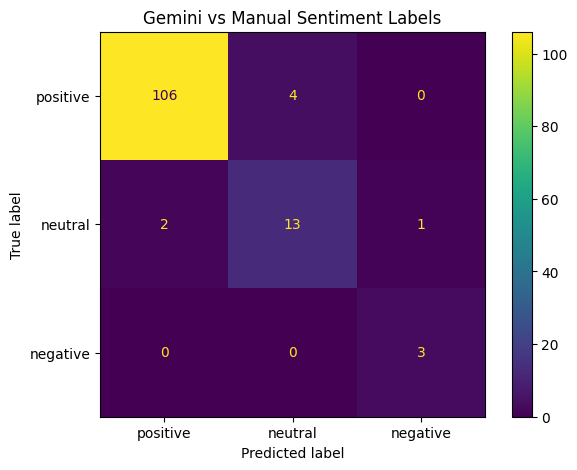

In [36]:
#6. Create Confusion Matrix
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
)

labels = [
    "positive",
    "neutral",
    "negative",
]

cm = confusion_matrix(
    validation_results_df["manual_sentiment"],
    validation_results_df["gemini_sentiment"],
    labels=labels,
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

fig, ax = plt.subplots(figsize=(7, 5))

display_cm.plot(
    ax=ax,
    values_format="d",
)

plt.title(
    "Gemini vs Manual Sentiment Labels"
)

plt.show()

In [37]:
#7. Analyze Disagreements
disagreements_df = validation_results_df[
    validation_results_df["manual_sentiment"]
    != validation_results_df["gemini_sentiment"]
].copy()

print(
    f"Total disagreements: "
    f"{len(disagreements_df)}"
)

print(
    f"Agreement rate: "
    f"{1 - len(disagreements_df) / len(validation_results_df):.2%}"
)

display(
    disagreements_df[
        [
            "review_text",
            "manual_sentiment",
            "gemini_sentiment",
        ]
    ]
)

Total disagreements: 7
Agreement rate: 94.57%


,review_text,manual_sentiment,gemini_sentiment
13,It’s decent but definitely not the best. It looks pretty aesthetic and definitely how the photos look. It is a tad cheap and “shaky” but it works ...,neutral,positive
61,Power selector cracks in a few weeks.. Good light except for the power switch. After a few weeks the on and off touch switch just cracks. I had it...,positive,neutral
66,"So comfortable for walking. I really like these Skechers. They’re very comfortable and have a lot of cushioning, which makes a big difference when...",neutral,positive
68,Gets the job done. I ordered this Philips Sonicare 3300 rechargable electric toothbrush to compare with my current electric toothbrush. What I lik...,neutral,negative
83,"Would be 5 stars but, The block has to grow on me.. These knives are extremely sharp!! The handles are very well made and comfortable. Everything ...",positive,neutral
103,"Love the Brand, this style is Eh. I truly love this brand. I have a couple pairs I’ve ordered from here and have had nothing but quality sunglasse...",positive,neutral
122,"For light use only, will not hold up for daily use of a 160lb person.. Great for moderate use. I bought this chair March of 2025 because I was goi...",positive,neutral


In [38]:
#8. Save Validation Results
VALIDATION_RESULTS_FILE = (
    "gemini_manual_validation_results.csv"
)

validation_results_df.to_csv(
    VALIDATION_RESULTS_FILE,
    index=False,
)

print(
    f"Saved validation results to: "
    f"{VALIDATION_RESULTS_FILE}"
)

Saved validation results to: gemini_manual_validation_results.csv


#Section 7 — Exploratory Data Analysis (EDA) for Review Sentiment

In [39]:
#1 Dataset overview
print("=" * 60)
print("SENTIMENT DATASET OVERVIEW")
print("=" * 60)

print(f"Total reviews: {len(labeled_df)}")

print("\nMissing sentiment labels:")
print(labeled_df["sentiment_label"].isna().sum())

print("\nSentiment distribution:")
print(labeled_df["sentiment_label"].value_counts())

print("\nSentiment percentage:")
print(
    labeled_df["sentiment_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

SENTIMENT DATASET OVERVIEW
Total reviews: 7494

Missing sentiment labels:
0

Sentiment distribution:
sentiment_label
positive    6524
neutral      526
negative     444
Name: count, dtype: int64

Sentiment percentage:
sentiment_label
positive    87.06
neutral      7.02
negative     5.92
Name: proportion, dtype: float64


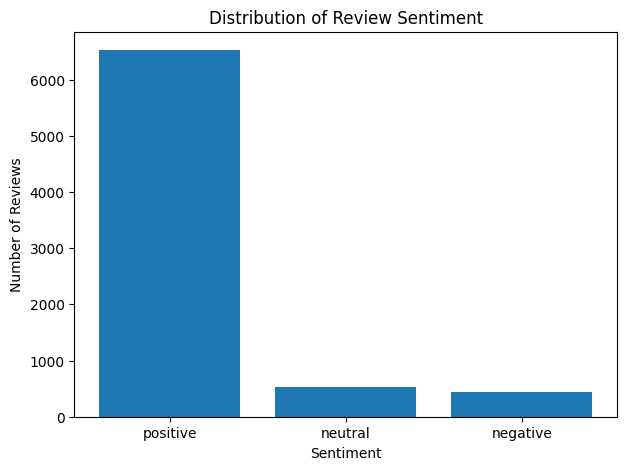

In [40]:
#2 Sentiment Class Distribution
import matplotlib.pyplot as plt

sentiment_counts = (
    labeled_df["sentiment_label"]
    .value_counts()
)

plt.figure(figsize=(7, 5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
)

plt.title("Distribution of Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [41]:
#3 Review Length Analysis
eda_df = labeled_df.copy()

eda_df["review_word_count"] = (
    eda_df["review_text"]
    .fillna("")
    .str.split()
    .str.len()
)

eda_df["review_char_count"] = (
    eda_df["review_text"]
    .fillna("")
    .str.len()
)

eda_df.groupby(
    "sentiment_label"
)[
    ["review_word_count", "review_char_count"]
].agg(
    ["mean", "median", "min", "max"]
).round(2)

review_word_count                  review_char_count         \
                             mean median min   max              mean median   
sentiment_label                                                               
negative                   136.18   73.0   5   999            735.62  392.0   
neutral                    202.30  141.0   2  1900           1081.84  738.0   
positive                   122.66   76.0   2  2432            674.68  416.0   

                            
                min    max  
sentiment_label             
negative         24   5374  
neutral          10  10609  
positive         10  13136

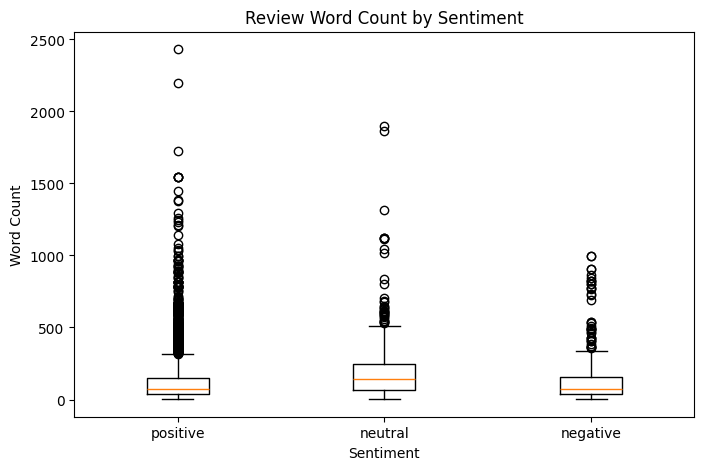

In [42]:
#Visualize review length by sentiment
sentiments = ["positive", "neutral", "negative"]

data = [
    eda_df.loc[
        eda_df["sentiment_label"] == sentiment,
        "review_word_count"
    ]
    for sentiment in sentiments
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    data,
    tick_labels=sentiments,
)

plt.title("Review Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")

plt.show()

In [43]:
#4 Star Rating vs Sentiment
rating_sentiment = pd.crosstab(
    eda_df["star_rating"],
    eda_df["sentiment_label"],
    normalize="index",
) * 100

print(
    rating_sentiment.round(2)
)

sentiment_label  negative  neutral  positive
star_rating                                 
1.0                 98.95     1.05      0.00
2.0                 95.12     4.88      0.00
3.0                 56.49    43.51      0.00
4.0                  4.90    37.66     57.44
5.0                  0.12     0.35     99.53


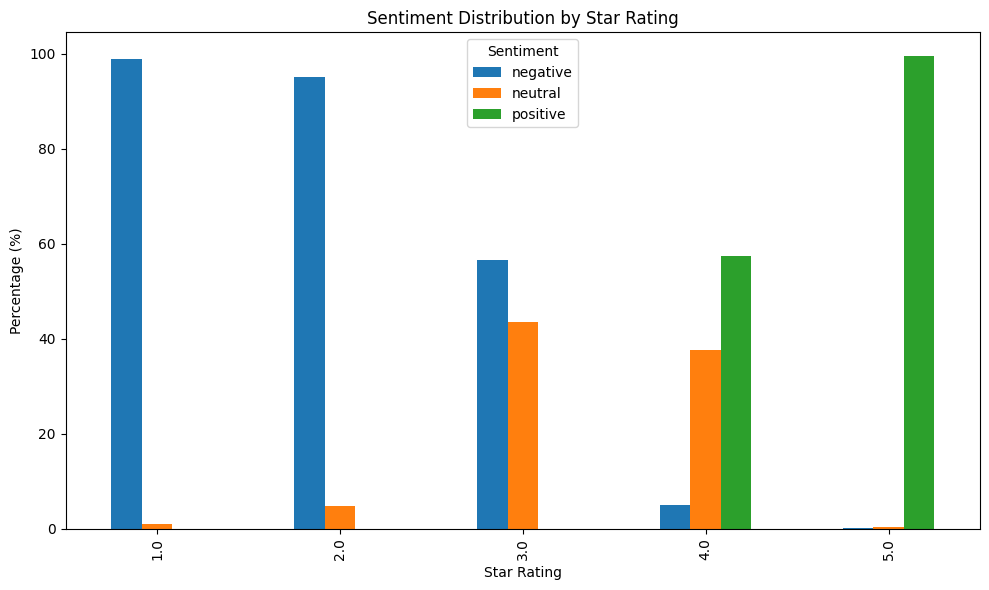

In [44]:
rating_sentiment.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title(
    "Sentiment Distribution by Star Rating"
)

plt.xlabel("Star Rating")
plt.ylabel("Percentage (%)")

plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

In [45]:
#5 Sentiment Distribution by Search Keyword
keyword_sentiment = pd.crosstab(
    eda_df["search_keyword"],
    eda_df["sentiment_label"],
    normalize="index",
) * 100

keyword_sentiment = keyword_sentiment.round(2)

display(keyword_sentiment)

sentiment_label,negative,neutral,positive
search_keyword,,,
DSLR camera,8.59,8.59,82.81
USB-C hub,7.10,5.92,86.98
air purifier,1.56,8.59,89.84
backpack,2.34,5.47,92.19
bluetooth speaker,0.88,8.77,90.35
budget laptop,17.18,7.98,74.85
candle,6.60,6.38,87.02
coffee maker,10.68,10.16,79.17
desk lamp LED,3.46,3.67,92.87


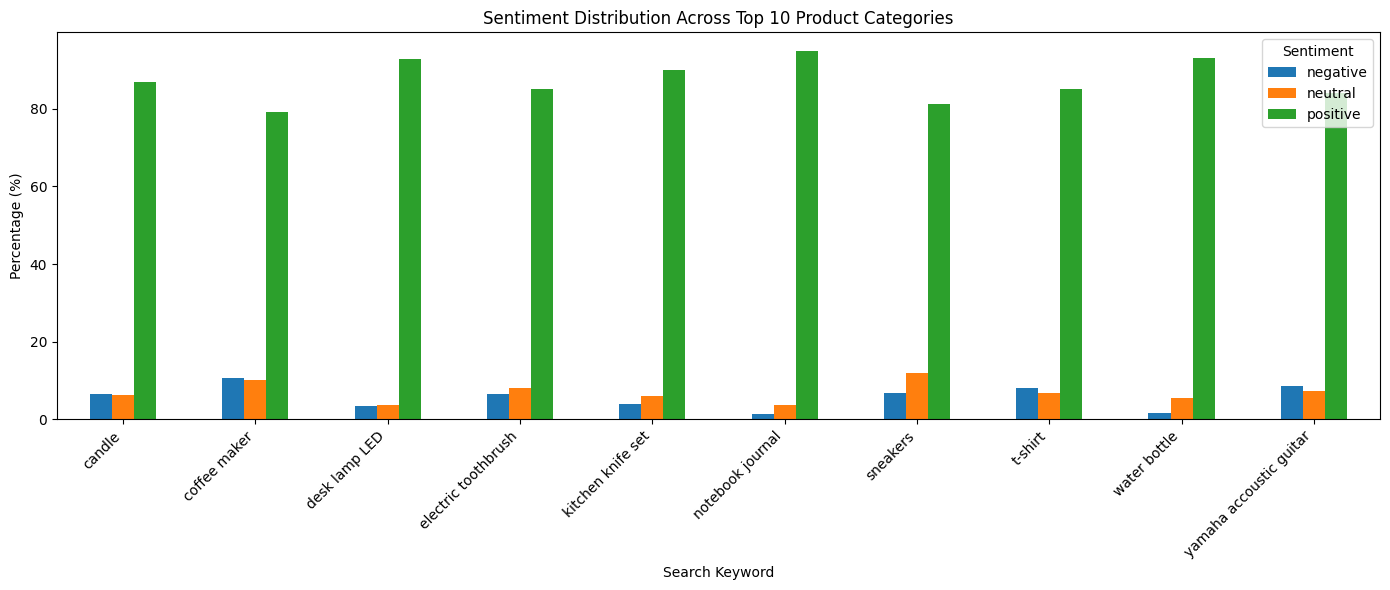

In [46]:
top_keywords = (
    eda_df["search_keyword"]
    .value_counts()
    .head(10)
    .index
)

top_keyword_df = eda_df[
    eda_df["search_keyword"].isin(top_keywords)
]

top_keyword_sentiment = pd.crosstab(
    top_keyword_df["search_keyword"],
    top_keyword_df["sentiment_label"],
    normalize="index",
) * 100

top_keyword_sentiment.plot(
    kind="bar",
    figsize=(14, 6),
)

plt.title(
    "Sentiment Distribution Across Top 10 Product Categories"
)

plt.xlabel("Search Keyword")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45, ha="right")

plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()


In [47]:
#6 Most Common Words by Sentiment
from sklearn.feature_extraction.text import CountVectorizer

for sentiment in [
    "positive",
    "neutral",
    "negative",
]:

    texts = eda_df.loc[
        eda_df["sentiment_label"] == sentiment,
        "review_text"
    ].dropna()

    vectorizer = CountVectorizer(
        stop_words="english",
        max_features=15,
    )

    word_matrix = vectorizer.fit_transform(texts)

    word_counts = (
        pd.DataFrame(
            {
                "word": vectorizer.get_feature_names_out(),
                "count": word_matrix.sum(axis=0).A1,
            }
        )
        .sort_values(
            "count",
            ascending=False,
        )
    )

    print("\n" + "=" * 50)
    print(
        f"TOP WORDS — {sentiment.upper()}"
    )
    print("=" * 50)

    display(word_counts)


TOP WORDS — POSITIVE


,word,count
3,great,5486
13,use,3145
5,like,3120
2,good,3107
10,quality,2705
4,just,2610
1,easy,2549
6,love,2480
9,price,2019
11,really,2004



TOP WORDS — NEUTRAL


,word,count
7,like,506
4,good,435
6,just,380
12,use,342
5,great,288
10,really,244
11,time,242
3,don,240
8,nice,225
9,quality,205



TOP WORDS — NEGATIVE


,word,count
5,just,227
6,like,170
1,coffee,170
9,quality,155
11,use,151
0,chair,147
3,good,146
10,time,141
4,great,126
7,machine,124


In [48]:
# Save final labeled review dataset
FINAL_LABELED_FILE = "review_sentiment_labeled.csv"

labeled_df.to_csv(
    FINAL_LABELED_FILE,
    index=False
)

print(f"Saved successfully: {FINAL_LABELED_FILE}")
print(f"Dataset shape: {labeled_df.shape}")

# Verify
display(labeled_df.head())

Saved successfully: review_sentiment_labeled.csv
Dataset shape: (7494, 13)


,product_number,asin,search_keyword,product_title,brand,product_price,average_rating,reviewer_name,star_rating,review_title,review_description,review_text,sentiment_label
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Needsmorenails,5.0,"Durable, Excellent sound, Great value","While not a user of these earbuds, personally, I gave them as gifts to several people. When I asked how the earbuds were doing, I was told that th...","Durable, Excellent sound, Great value. While not a user of these earbuds, personally, I gave them as gifts to several people. When I asked how the...",positive
1,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,J. Marie,5.0,Great Sound Quality,"Pleasantly Surprised. Great sound, easy to use, hold a charge for more than 8 hours. Comfortable even with glasses.","Great Sound Quality. Pleasantly Surprised. Great sound, easy to use, hold a charge for more than 8 hours. Comfortable even with glasses.",positive
2,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Edie Keepsfire,4.0,"Honestly, shoulda been five except for a 3/5 on call quality, and a couple notes","I've bought these twice. I'll probably buy them a third time. Since they're earbuds, let's talk earbud importance: Calls: Almost gave 3/5 because ...","Honestly, shoulda been five except for a 3/5 on call quality, and a couple notes. I've bought these twice. I'll probably buy them a third time. Si...",positive
3,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Stuck in the Desert,5.0,Great Quality! Affordable Price!,I really like these earbuds because they have the ear hook. They are perfect for someone who has small ear canals. I would highly recommend them!,Great Quality! Affordable Price!. I really like these earbuds because they have the ear hook. They are perfect for someone who has small ear canal...,positive
4,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,25.99,4.4,Alicia Martino-Crawford,5.0,Very useful and cute,I mainly use these earbuds when working out at the gym The sound quality is good. I love the secure fit. It's helpful to have the feature where it...,Very useful and cute. I mainly use these earbuds when working out at the gym The sound quality is good. I love the secure fit. It's helpful to hav...,positive


In [49]:
from google.colab import files

files.download("review_sentiment_labeled.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### EDA Findings and Interpretation

The review sentiment dataset contains 7,494 labeled reviews. The sentiment distribution is highly imbalanced, with positive reviews accounting for 87.06% of the dataset, while neutral and negative reviews account for only 7.02% and 5.92%, respectively. Therefore, accuracy alone would not be a sufficient evaluation metric during model development. Macro F1-score and class-level performance metrics will be prioritized to ensure that minority sentiment classes are evaluated fairly.

A strong relationship was observed between customer star ratings and the generated sentiment labels. Reviews with one and two stars were overwhelmingly classified as negative, while five-star reviews were almost entirely positive. Three-star reviews showed a mixture of negative and neutral sentiment, reflecting the more ambiguous and mixed nature of moderately rated products. This pattern provides additional evidence that the generated sentiment labels are logically consistent with customer feedback.

The word frequency analysis showed that positive reviews commonly contain terms such as "great," "good," "quality," "easy," "love," and "perfect." However, several frequently occurring words also appear across neutral and negative reviews. This indicates that sentiment cannot always be determined from individual keywords alone, as the surrounding context significantly influences meaning. Therefore, context-aware text classification approaches will be explored during model development.
